# Monter Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Verification du dataset

In [ ]:
from pathlib import Path

RAW_DATA_DIR = Path("/content/drive/MyDrive/Projet_IA/dataset")
FIRE_DIR = RAW_DATA_DIR / "fire"
SMOKE_DIR = RAW_DATA_DIR / "smoke"

print("Fire exists:", FIRE_DIR.exists())
print("Smoke exists:", SMOKE_DIR.exists())
print("Fire count:", len(list(FIRE_DIR.glob("*"))))
print("Smoke count:", len(list(SMOKE_DIR.glob("*"))))

Fire exists: True
Smoke exists: True
Fire count: 1102
Smoke count: 1102


# Imports et paramètres

In [ ]:
!pip -q install tensorflow scikit-learn matplotlib seaborn opencv-python

In [ ]:
import os
import random
import shutil
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications.inception_resnet_v2 import InceptionResNetV2, preprocess_input
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Reproductibilité et configuration générale

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (224, 224)   # cohérent avec la figure de la méthodologie de l’article
BATCH_SIZE = 55         # valeur de l’article
EPOCHS = 10
THRESHOLD_NON_FIRE = 0.043

RAW_DATA_DIR = Path("/content/drive/MyDrive/Projet_IA/dataset")
BALANCED_DATA_DIR = Path("/content/fire_smoke_balanced")
SPLIT_DATA_DIR = Path("/content/fire_smoke_split")

FIRE_DIR = RAW_DATA_DIR / "fire"
SMOKE_DIR = RAW_DATA_DIR / "smoke"

# vérification
print("RAW_DATA_DIR:", RAW_DATA_DIR)
print("FIRE_DIR exists:", FIRE_DIR.exists())
print("SMOKE_DIR exists:", SMOKE_DIR.exists())

# nombre d’images
print("Fire images:", len(list(FIRE_DIR.glob("*"))))
print("Smoke images:", len(list(SMOKE_DIR.glob("*"))))

RAW_DATA_DIR: /content/drive/MyDrive/Projet_IA/dataset
FIRE_DIR exists: True
SMOKE_DIR exists: True
Fire images: 1102
Smoke images: 1102


# Lister et vérifier les images

In [ ]:
def list_images(folder):
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    return sorted([p for p in Path(folder).iterdir() if p.suffix.lower() in exts])

fire_images = list_images(FIRE_DIR)
smoke_images = list_images(SMOKE_DIR)

print("Fire images:", len(fire_images))
print("Smoke images:", len(smoke_images))
print("Some fire samples:", [p.name for p in fire_images[:5]])
print("Some smoke samples:", [p.name for p in smoke_images[:5]])

Fire images: 1102
Smoke images: 1102
Some fire samples: ['1.png', '132343342_21n.jpg', '14.jpg', '2.png', '20130611_100618_Black-Forest-Fire-engulfs-house.jpg']
Some smoke samples: ['000001.jpg', '000002.jpg', '000003.jpg', '000004.jpg', '000005.jpg']


# Créer un dataset équilibré

In [ ]:
def recreate_dir(path):
    path = Path(path)
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)

recreate_dir(BALANCED_DATA_DIR)
(BALANCED_DATA_DIR / "fire").mkdir(parents=True, exist_ok=True)
(BALANCED_DATA_DIR / "smoke").mkdir(parents=True, exist_ok=True)

# On prend 1102 par classe
n_per_class = 1102

selected_fire = fire_images[:min(n_per_class, len(fire_images))]
selected_smoke = random.sample(smoke_images, min(n_per_class, len(smoke_images)))

for src in selected_fire:
    shutil.copy2(src, BALANCED_DATA_DIR / "fire" / src.name)

for src in selected_smoke:
    shutil.copy2(src, BALANCED_DATA_DIR / "smoke" / src.name)

print("Balanced fire:", len(list_images(BALANCED_DATA_DIR / "fire")))
print("Balanced smoke:", len(list_images(BALANCED_DATA_DIR / "smoke")))

Balanced fire: 1102
Balanced smoke: 1102


# Créer le split train / validation / test

In [ ]:
recreate_dir(SPLIT_DATA_DIR)

for split in ["train", "val", "test"]:
    for cls in ["fire", "smoke"]:
        (SPLIT_DATA_DIR / split / cls).mkdir(parents=True, exist_ok=True)

def split_and_copy_class_files(class_dir, class_name, test_size=0.10, val_size=0.10):
    files = list_images(class_dir)
    train_val_files, test_files = train_test_split(
        files, test_size=test_size, random_state=SEED, shuffle=True
    )

    # val_size est relatif au train_val restant
    val_ratio_in_trainval = val_size / (1.0 - test_size)
    train_files, val_files = train_test_split(
        train_val_files, test_size=val_ratio_in_trainval, random_state=SEED, shuffle=True
    )

    for src in train_files:
        shutil.copy2(src, SPLIT_DATA_DIR / "train" / class_name / src.name)
    for src in val_files:
        shutil.copy2(src, SPLIT_DATA_DIR / "val" / class_name / src.name)
    for src in test_files:
        shutil.copy2(src, SPLIT_DATA_DIR / "test" / class_name / src.name)

split_and_copy_class_files(BALANCED_DATA_DIR / "fire", "fire")
split_and_copy_class_files(BALANCED_DATA_DIR / "smoke", "smoke")

def count_split(split):
    fire_n = len(list_images(SPLIT_DATA_DIR / split / "fire"))
    smoke_n = len(list_images(SPLIT_DATA_DIR / split / "smoke"))
    return fire_n, smoke_n, fire_n + smoke_n

for split in ["train", "val", "test"]:
    f, s, total = count_split(split)
    print(split, "=> fire:", f, "smoke:", s, "total:", total)

train => fire: 880 smoke: 880 total: 1760
val => fire: 111 smoke: 111 total: 222
test => fire: 111 smoke: 111 total: 222


# Visualiser quelques images

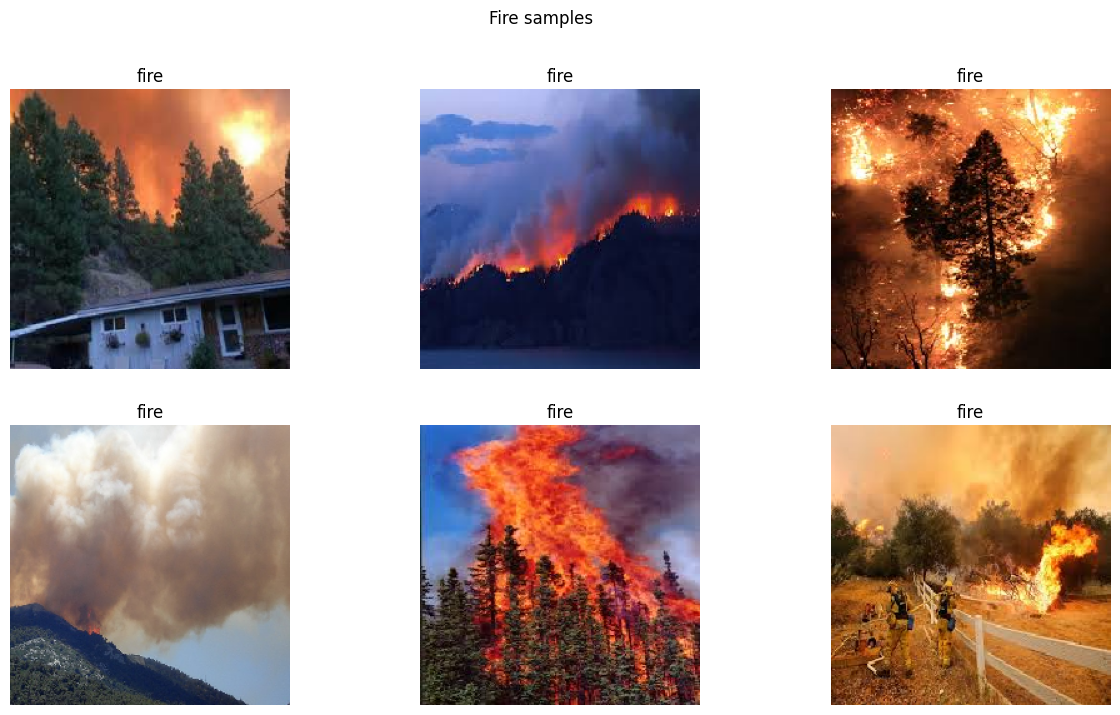

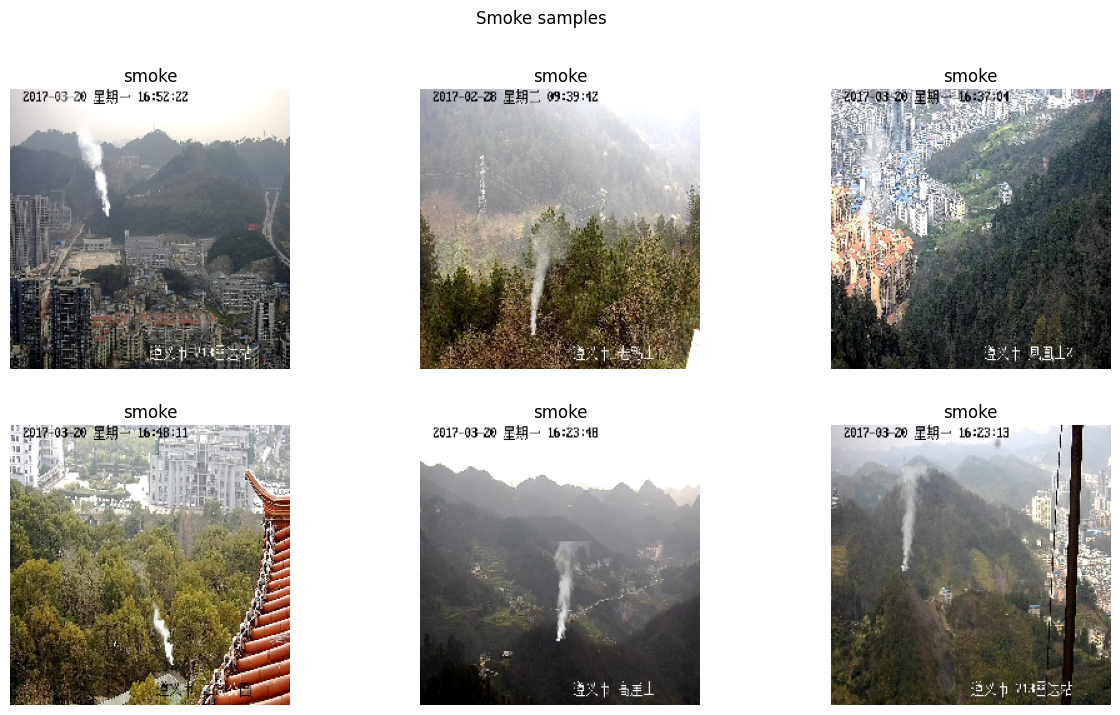

In [ ]:
def show_samples_from_folder(folder, n=6, title="Samples"):
    imgs = list_images(folder)
    chosen = random.sample(imgs, min(n, len(imgs)))
    plt.figure(figsize=(15, 8))
    for i, p in enumerate(chosen, 1):
        img = load_img(p, target_size=IMG_SIZE)
        ax = plt.subplot(2, 3, i)
        plt.imshow(img)
        plt.title(p.parent.name)
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

show_samples_from_folder(BALANCED_DATA_DIR / "fire", title="Fire samples")
show_samples_from_folder(BALANCED_DATA_DIR / "smoke", title="Smoke samples")

# Générateurs de données avec augmentation

In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    zoom_range=0.10,              # scaling
    horizontal_flip=True,
    vertical_flip=True
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    SPLIT_DATA_DIR / "train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_gen = val_test_datagen.flow_from_directory(
    SPLIT_DATA_DIR / "val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    SPLIT_DATA_DIR / "test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("Class indices:", train_gen.class_indices)

Found 1760 images belonging to 2 classes.
Found 222 images belonging to 2 classes.
Found 222 images belonging to 2 classes.
Class indices: {'fire': 0, 'smoke': 1}


# Construire le modèle Inception-ResNet-v2

In [ ]:
base_model = InceptionResNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

base_model.trainable = False  # phase 1 : entraînement de la tête de classification

inputs = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.45)(x)   # valeur de l’article
outputs = Dense(2, activation="softmax")(x)

model = Model(inputs, outputs)
model.summary()

219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_resnet_v2             │ (None, 5, 5, 1536)     │    54,336,736 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         3,074 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,339,810 (207.29 MB)

 Trainable params: 3,074 (12.01 KB)

 Non-trainable params: 54,336,736 (207.28 MB)

# Compiler le modèle

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-3, beta_1=0.99),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Callbacks

In [ ]:
checkpoint_path = "/content/best_fire_smoke.keras"

callbacks = [
    ModelCheckpoint(
        checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1,
        min_lr=1e-7
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    )
]

# Entraîner le modèle

In [ ]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7766 - loss: 0.4552   
Epoch 1: val_loss improved from None to 0.10842, saving model to /content/best_fire_smoke.keras

Epoch 1: finished saving model to /content/best_fire_smoke.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.8619 - loss: 0.3114 - val_accuracy: 0.9505 - val_loss: 0.1084 - learning_rate: 0.0010
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9464 - loss: 0.1251
Epoch 2: val_loss improved from 0.10842 to 0.07884, saving model to /content/best_fire_smoke.keras

Epoch 2: finished saving model to /content/best_fire_smoke.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.9500 - loss: 0.1187 - val_accuracy: 0.9685 - val_loss: 0.0788 - learning_rate: 0.0010
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 991ms/step - accuracy: 0.9625 - loss: 0.1120
Epoch 3: val_loss improved from 0.07884 to 0.05621, saving model to /content/best_fire_smoke.keras

Epoch 3: finished saving model to /conte

# Tracer accuracy et loss

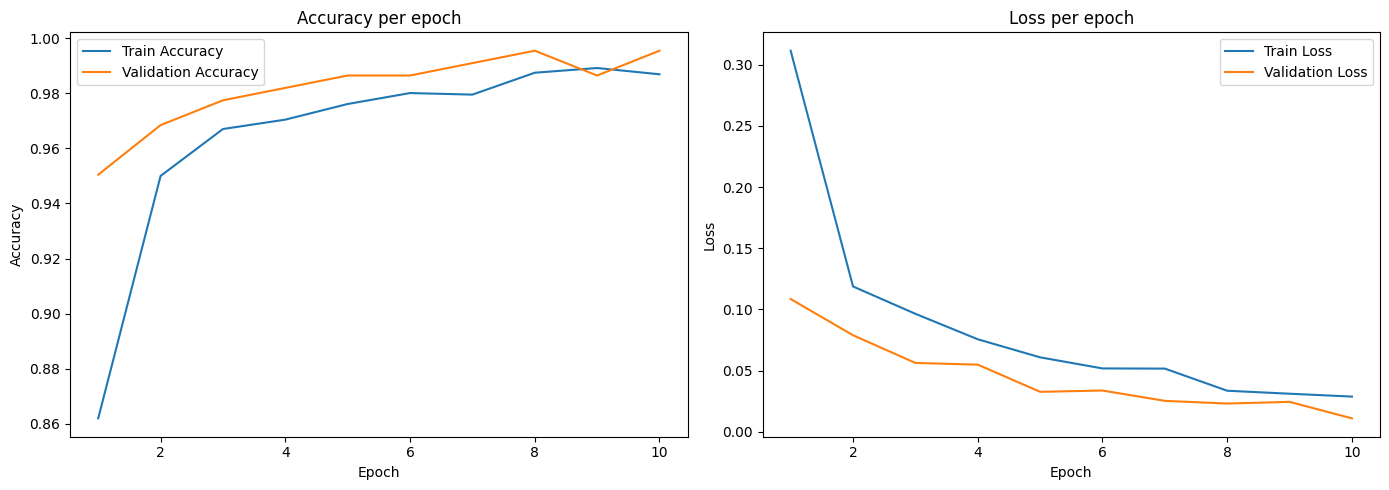

In [ ]:
def plot_history(hist):
    acc = hist.history.get("accuracy", [])
    val_acc = hist.history.get("val_accuracy", [])
    loss = hist.history.get("loss", [])
    val_loss = hist.history.get("val_loss", [])

    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label="Train Accuracy")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Accuracy per epoch")

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label="Train Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Loss per epoch")

    plt.tight_layout()
    plt.show()

plot_history(history)

# Charger le meilleur modèle

In [ ]:
best_model = tf.keras.models.load_model(checkpoint_path)

# Évaluer sur le test set

In [ ]:
test_probs = best_model.predict(test_gen, verbose=1)
y_true = test_gen.classes
y_pred = np.argmax(test_probs, axis=1)

class_indices = train_gen.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}

print("Class indices:", class_indices)
print("Index to class:", idx_to_class)

# On prend fire comme classe positive, comme dans l'article
pos_index = class_indices["fire"]

y_true_bin = (y_true == pos_index).astype(int)
y_pred_bin = (y_pred == pos_index).astype(int)
y_score = test_probs[:, pos_index]

acc = accuracy_score(y_true_bin, y_pred_bin)
prec = precision_score(y_true_bin, y_pred_bin, zero_division=0)
rec = recall_score(y_true_bin, y_pred_bin, zero_division=0)
f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)

cm = confusion_matrix(y_true_bin, y_pred_bin)
tn, fp, fn, tp = cm.ravel()
spec = tn / (tn + fp + 1e-7)

print(f"Accuracy   : {acc:.4f}")
print(f"Precision  : {prec:.4f}")
print(f"Recall     : {rec:.4f}")
print(f"F1-score   : {f1:.4f}")
print(f"Specificity: {spec:.4f}")

print("\nClassification report:\n")
print(classification_report(y_true_bin, y_pred_bin, target_names=["Non-fire/smoke", "Fire"]))

5/5 ━━━━━━━━━━━━━━━━━━━━ 27s 4s/step
Class indices: {'fire': 0, 'smoke': 1}
Index to class: {0: 'fire', 1: 'smoke'}
Accuracy   : 0.9775
Precision  : 0.9649
Recall     : 0.9910
F1-score   : 0.9778
Specificity: 0.9640

Classification report:

                precision    recall  f1-score   support

Non-fire/smoke       0.99      0.96      0.98       111
          Fire       0.96      0.99      0.98       111

      accuracy                           0.98       222
     macro avg       0.98      0.98      0.98       222
  weighted avg       0.98      0.98      0.98       222



# Matrice de confusion

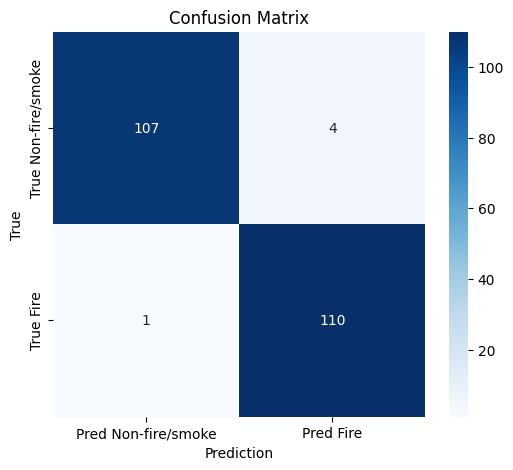

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Pred Non-fire/smoke", "Pred Fire"], yticklabels=["True Non-fire/smoke", "True Fire"])
plt.title("Confusion Matrix")
plt.xlabel("Prediction")
plt.ylabel("True")
plt.show()

# ROC curve et AUC

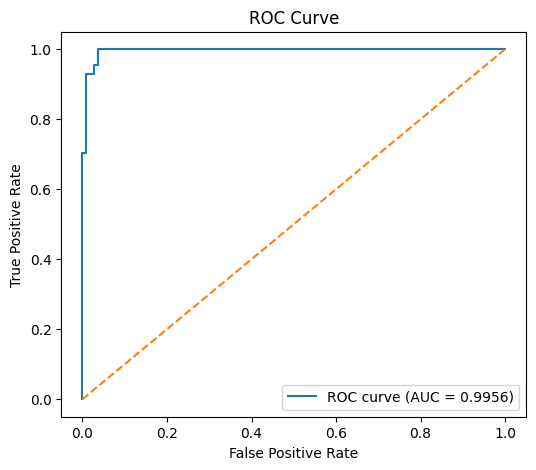

AUC: 0.9956172388604821


In [ ]:
fpr, tpr, thresholds = roc_curve(y_true_bin, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

print("AUC:", roc_auc)

# Precision-Recall curve

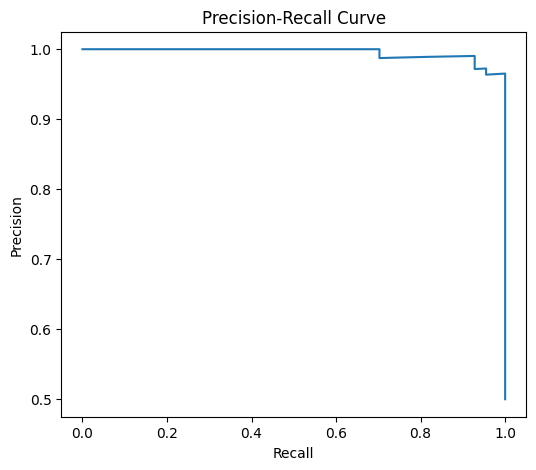

In [ ]:
#Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_true_bin, y_score)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

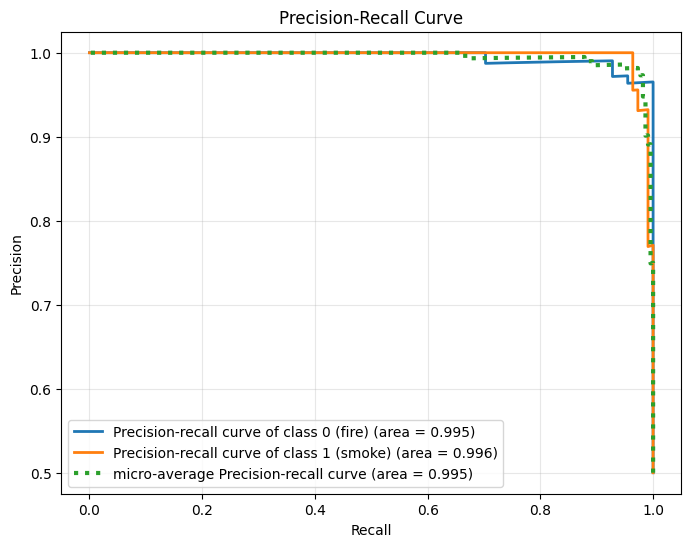

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

# Probabilités du modèle : shape = (n_samples, 2)
y_score = test_probs

# Vraies classes en one-hot : shape = (n_samples, 2)
y_true = to_categorical(test_gen.classes, num_classes=2)

class_indices = train_gen.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}

plt.figure(figsize=(8, 6))

# Courbes par classe
for i in range(2):
    precision_i, recall_i, _ = precision_recall_curve(y_true[:, i], y_score[:, i])
    ap_i = average_precision_score(y_true[:, i], y_score[:, i])
    class_name = idx_to_class[i]
    plt.plot(
        recall_i,
        precision_i,
        lw=2,
        label=f"Precision-recall curve of class {i} ({class_name}) (area = {ap_i:.3f})"
    )

# Micro-average
precision_micro, recall_micro, _ = precision_recall_curve(y_true.ravel(), y_score.ravel())
ap_micro = average_precision_score(y_true, y_score, average="micro")

plt.plot(
    recall_micro,
    precision_micro,
    linestyle=":",
    lw=3,
    label=f"micro-average Precision-recall curve (area = {ap_micro:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.show()

# Fonction de prédiction avec seuil “Non-fire”

In [ ]:
#Fonction de prédiction avec seuil “Non-fire”
def predict_image(image_path, model, threshold=THRESHOLD_NON_FIRE):
    img = load_img(image_path, target_size=IMG_SIZE)
    arr = img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    arr = preprocess_input(arr)

    probs = model.predict(arr, verbose=0)[0]
    best_idx = np.argmax(probs)
    best_prob = probs[best_idx]
    label = idx_to_class[best_idx]

    if best_prob < threshold:
        return "Non-fire", float(best_prob), probs

    return label, float(best_prob), probs

# Tester sur une image

Image: 800px-Fires_cross_a_hill_in_SoCal_October_2007.jpg
Prediction: fire
Confidence: 1.0
All probabilities: [1.0000000e+00 3.2756708e-09]


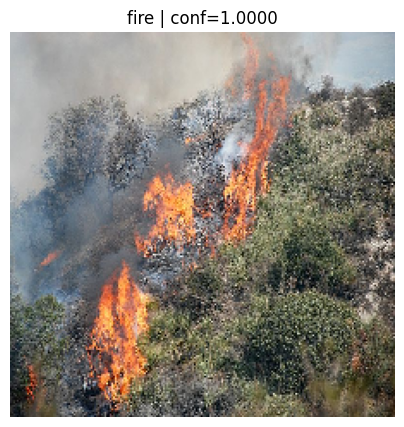

In [ ]:
sample_test_image = list_images(SPLIT_DATA_DIR / "test" / "fire")[0]  # ou smoke
label, prob, probs = predict_image(sample_test_image, best_model)

print("Image:", sample_test_image.name)
print("Prediction:", label)
print("Confidence:", prob)
print("All probabilities:", probs)

img = load_img(sample_test_image, target_size=IMG_SIZE)
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title(f"{label} | conf={prob:.4f}")
plt.axis("off")
plt.show()

# Détection sur une vidéo

In [ ]:
def predict_frame(frame, model, threshold=THRESHOLD_NON_FIRE):
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    img = cv2.resize(rgb, IMG_SIZE)
    arr = img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    arr = preprocess_input(arr)

    probs = model.predict(arr, verbose=0)[0]
    best_idx = np.argmax(probs)
    best_prob = probs[best_idx]
    label = idx_to_class[best_idx]

    if best_prob < threshold:
        return "Non-fire", float(best_prob)

    return label, float(best_prob)

# Vidéo de démonstration

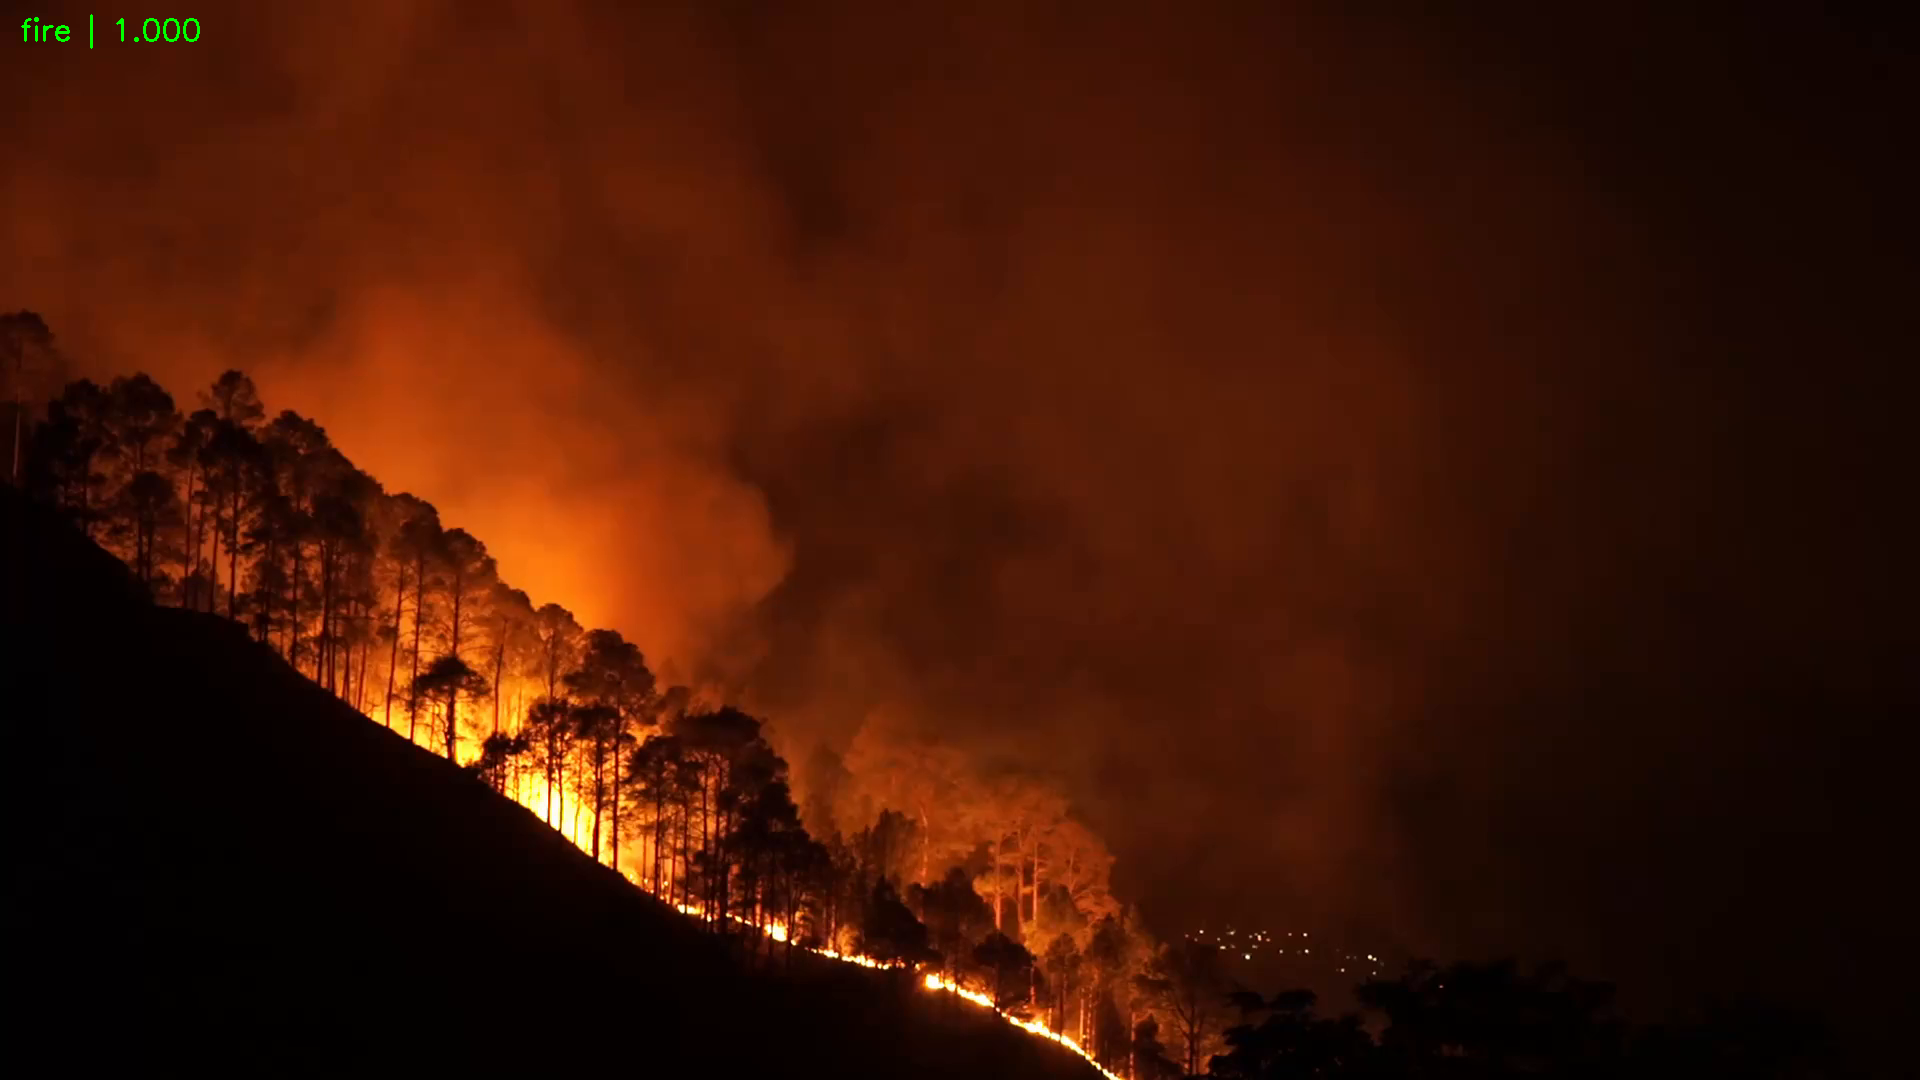

In [ ]:
#Vidéo de démonstration
from google.colab.patches import cv2_imshow
video_path = "/content/drive/MyDrive/Projet_IA/video_test_4.mp4"

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Impossible d'ouvrir la vidéo.")
else:
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        label, prob = predict_frame(frame, best_model)

        text = f"{label} | {prob:.3f}"
        cv2.putText(frame, text, (20, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 0), 2)

        cv2_imshow(frame)
        break

    cap.release()

# Sauvegarder le modèle et le mapping des classes

In [ ]:
best_model.save("/content/drive/MyDrive/Projet_IA/fire_smoke_model.keras")
import json
with open("/content/drive/MyDrive/Projet_IA/class_indices.json", "w") as f:
    json.dump(class_indices, f)

print("Model saved.")

Model saved.


# Recharger modèle

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from google.colab import drive
import json
import numpy as np
import cv2
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.applications.inception_resnet_v2 import preprocess_input
from tensorflow.keras.models import load_model
from google.colab.patches import cv2_imshow

drive.mount('/content/drive')
best_model = load_model("/content/drive/MyDrive/Projet_IA/fire_smoke_model.keras")

with open("/content/drive/MyDrive/Projet_IA/class_indices.json", "r") as f:
    class_indices = json.load(f)

idx_to_class = {v: k for k, v in class_indices.items()}
IMG_SIZE = (224, 224)
THRESHOLD_NON_FIRE = 0.043

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
